In [1]:
#102317129
window_size= 14
prediction_horizon= 3
hidden_size= 14

In [2]:
import numpy as np
#to convert raw time series into learning model format
#instead of predicting directly from a long sequence, we break
#it into smaller input-output pairs using a sliding window
def create_sequences(data, window_size, horizon):
    X, y =[], []

    for i in range(len(data) -window_size- horizon+1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

In [3]:
import torch
import torch.nn as nn
#from scratch immplementation of GRU
#processed step by step and maintains a hidden state
class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size =hidden_size

        self.update_gate=nn.Linear(input_size + hidden_size, hidden_size)
        self.reset_gate=nn.Linear(input_size + hidden_size, hidden_size)
        self.candidate=nn.Linear(input_size + hidden_size, hidden_size)

        self.fc =nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, input_size = x.size()
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(seq_len):
            x_t=x[:, t, :]

            combined= torch.cat((x_t, h), dim=1)
            #how much info to add
            z =torch.sigmoid(self.update_gate(combined))   #update
            #how much past info to be forgotten
            r=torch.sigmoid(self.reset_gate(combined))    #reset
            combined_reset =torch.cat((x_t, r*h), dim=1)
            h_tilde=torch.tanh(self.candidate(combined_reset))

            h =(1 -z)*h+z*h_tilde

        return self.fc(h)

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
      #flattenign to remove time structure
        x = x.view(x.size(0), -1)
        return self.model(x)

In [5]:
def train_model(model, train_loader, optimizer, criterion, epochs=20):
    model.train()

    losses=[]

    for epoch in range(epochs):
        total_loss=0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs=model(X_batch)
            loss=criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss+=loss.item()

        avg_loss=total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    return losses

In [7]:
import matplotlib.pyplot as plt

def plot_loss(losses):
    plt.figure()
    plt.plot(losses)
    plt.title("Training Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

In [8]:
def get_predictions(model, test_loader):
    model.eval()

    preds=[]
    actuals=[]

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs=model(X_batch)

            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())

    return np.concatenate(preds), np.concatenate(actuals)

def plot_predictions(y_true, y_pred, num_points=100):
    plt.figure()

    plt.plot(y_true[:num_points], label="Actual")
    plt.plot(y_pred[:num_points], label="Predicted")

    plt.title("Prediction vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()

    plt.show()

In [14]:
# evaluation function to compute regression mtrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return mse, mae, rmse

In [9]:
import pandas as pd

url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df=pd.read_csv(url)
print(df.head())

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


In [11]:
data = df["Temp"].values

In [12]:

data = pd.Series(data).fillna(method='ffill').values

#normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1,1)).flatten()

/tmp/ipykernel_20955/1113062016.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = pd.Series(data).fillna(method='ffill').values


(3634, 14) (3634, 3)
Epoch 1, Loss: 0.0563
Epoch 2, Loss: 0.0220
Epoch 3, Loss: 0.0209
Epoch 4, Loss: 0.0195
Epoch 5, Loss: 0.0178
Epoch 6, Loss: 0.0151
Epoch 7, Loss: 0.0125
Epoch 8, Loss: 0.0119
Epoch 9, Loss: 0.0118
Epoch 10, Loss: 0.0117
Epoch 11, Loss: 0.0116
Epoch 12, Loss: 0.0116
Epoch 13, Loss: 0.0116
Epoch 14, Loss: 0.0115
Epoch 15, Loss: 0.0115
Epoch 16, Loss: 0.0115
Epoch 17, Loss: 0.0114
Epoch 18, Loss: 0.0114
Epoch 19, Loss: 0.0114
Epoch 20, Loss: 0.0114
Epoch 1, Loss: 0.0511
Epoch 2, Loss: 0.0125
Epoch 3, Loss: 0.0122
Epoch 4, Loss: 0.0119
Epoch 5, Loss: 0.0117
Epoch 6, Loss: 0.0115
Epoch 7, Loss: 0.0114
Epoch 8, Loss: 0.0113
Epoch 9, Loss: 0.0113
Epoch 10, Loss: 0.0112
Epoch 11, Loss: 0.0112
Epoch 12, Loss: 0.0112
Epoch 13, Loss: 0.0111
Epoch 14, Loss: 0.0111
Epoch 15, Loss: 0.0111
Epoch 16, Loss: 0.0111
Epoch 17, Loss: 0.0111
Epoch 18, Loss: 0.0111
Epoch 19, Loss: 0.0111
Epoch 20, Loss: 0.0111


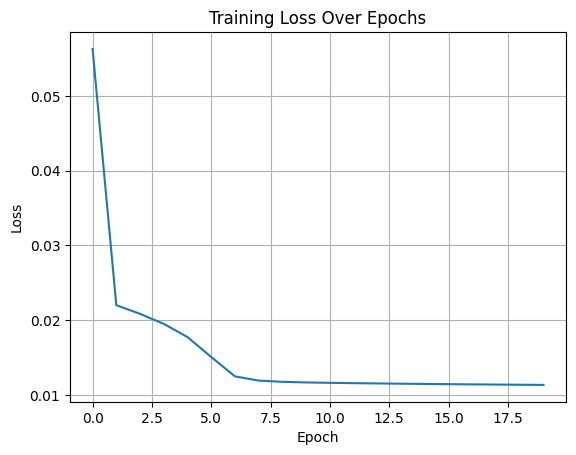

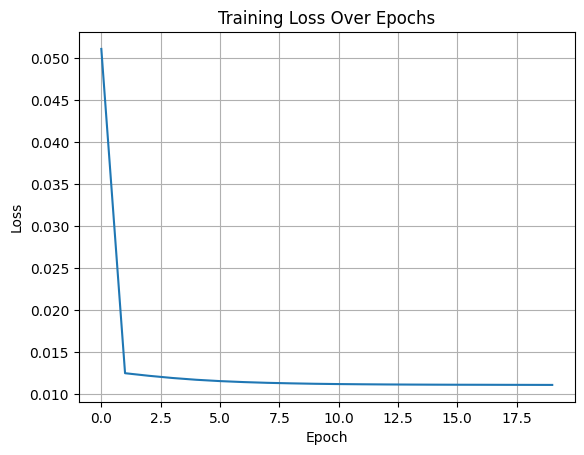

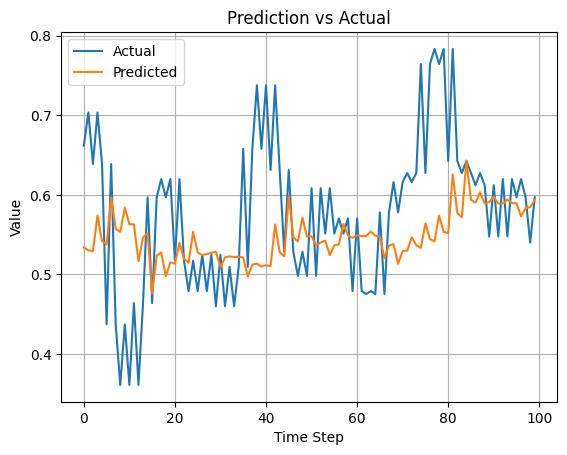

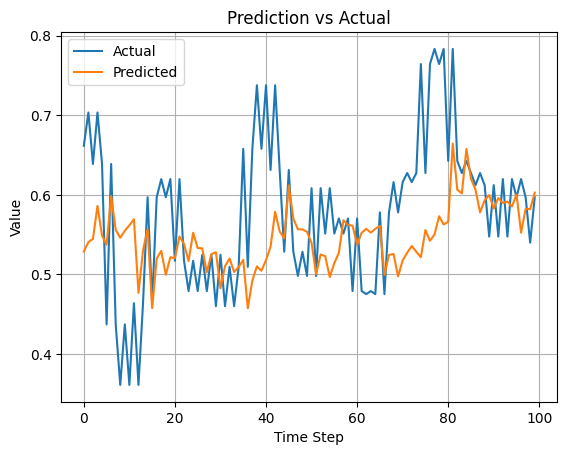

gru -> mse: 0.009429342113435268 mae: 0.07528739422559738 rmse: 0.09710479964159995


In [15]:
#step 1:convert time series into supervised learning format using sliding windows
#each input x contains past 14 values and each y contains next 3 values
X, y=create_sequences(data, window_size=14, horizon=3)

print(X.shape, y.shape)


#step 2: perform chronological train-test split
split = int(0.8 * len(X))

X_train, X_test=X[:split], X[split:]
y_train, y_test=y[:split], y[split:]


#step 3: convert numpy arrays to pytorch tensors
import torch

X_train=torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train=torch.tensor(y_train, dtype=torch.float32)

X_test=torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test=torch.tensor(y_test, dtype=torch.float32)


# step 4: create dataloaders for efficiency
from torch.utils.data import DataLoader, TensorDataset

train_loader=DataLoader(TensorDataset(X_train, y_train), batch_size=32)
test_loader =DataLoader(TensorDataset(X_test, y_test), batch_size=32)


# step 5: initialize models
model_gru = CustomGRU(input_size=1, hidden_size=14, output_size=3)
model_mlp = MLP(input_size=14, output_size=3)


# step 6:define loss function and optimizers
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()

optimizer_gru =optim.Adam(model_gru.parameters(), lr=0.001)
optimizer_mlp=optim.Adam(model_mlp.parameters(), lr=0.001)


#step 7: train both models
losses_gru = train_model(model_gru, train_loader, optimizer_gru, criterion)
losses_mlp = train_model(model_mlp, train_loader, optimizer_mlp, criterion)


#step 8: plot training loss curves
plot_loss(losses_gru)
plot_loss(losses_mlp)


#step 9: generate predictions on unseen test data
preds_gru, actuals = get_predictions(model_gru, test_loader)
preds_mlp, _ = get_predictions(model_mlp, test_loader)


#step 10: plot predicted vs actual
plot_predictions(actuals.flatten(), preds_gru.flatten())
plot_predictions(actuals.flatten(), preds_mlp.flatten())


#step 11: compute evaluation metrics
mse, mae, rmse = evaluate(actuals.flatten(), preds_gru.flatten())

print("gru -> mse:", mse, "mae:", mae, "rmse:", rmse)



window_sizes = [7, 14, 28]

In [19]:
import numpy as np
import pandas as pd
np.random.seed(42)

time = np.arange(0, 2000)
data = (
    50
    + 10 * np.sin(2 * np.pi * time / 24)   # daily cycle
    + 5 * np.sin(2 * np.pi * time / 168)  # weekly cycle
    + np.random.normal(0, 2, len(time))   # noise
)
data = pd.Series(data).values

print(data[:10])

[50.99342831 52.49861782 56.66902754 60.67694991 58.93715862 60.12054238
 64.2710303  62.48822295 59.19508114 59.80758321]


(1984, 14) (1984, 3)
Epoch 1, Loss: 2612.3412
Epoch 2, Loss: 2511.8260
Epoch 3, Loss: 2382.0922
Epoch 4, Loss: 2295.9460
Epoch 5, Loss: 2219.3748
Epoch 6, Loss: 2147.2865
Epoch 7, Loss: 2078.2947
Epoch 8, Loss: 2011.7891
Epoch 9, Loss: 1947.4359
Epoch 10, Loss: 1885.0264
Epoch 11, Loss: 1824.4171
Epoch 12, Loss: 1765.5022
Epoch 13, Loss: 1708.1998
Epoch 14, Loss: 1652.4431
Epoch 15, Loss: 1598.1761
Epoch 16, Loss: 1545.3504
Epoch 17, Loss: 1493.9235
Epoch 18, Loss: 1443.8570
Epoch 19, Loss: 1395.1158
Epoch 20, Loss: 1347.6677
Epoch 1, Loss: 768.2374
Epoch 2, Loss: 74.7995
Epoch 3, Loss: 63.9378
Epoch 4, Loss: 53.8894
Epoch 5, Loss: 43.8791
Epoch 6, Loss: 34.6732
Epoch 7, Loss: 26.9683
Epoch 8, Loss: 20.9501
Epoch 9, Loss: 16.4545
Epoch 10, Loss: 13.2277
Epoch 11, Loss: 11.0246
Epoch 12, Loss: 9.6098
Epoch 13, Loss: 8.7584
Epoch 14, Loss: 8.2754
Epoch 15, Loss: 8.0135
Epoch 16, Loss: 7.8748
Epoch 17, Loss: 7.8006
Epoch 18, Loss: 7.7595
Epoch 19, Loss: 7.7342
Epoch 20, Loss: 7.7170


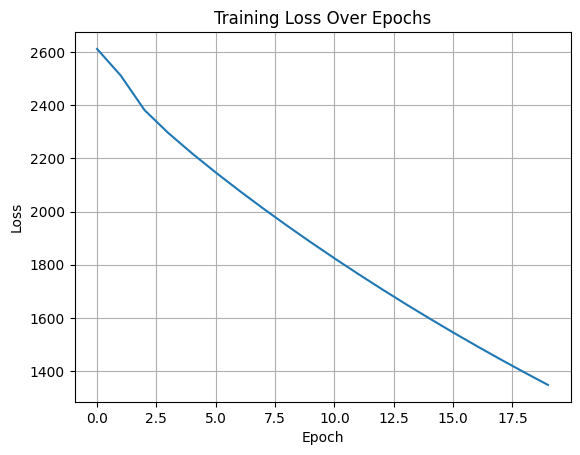

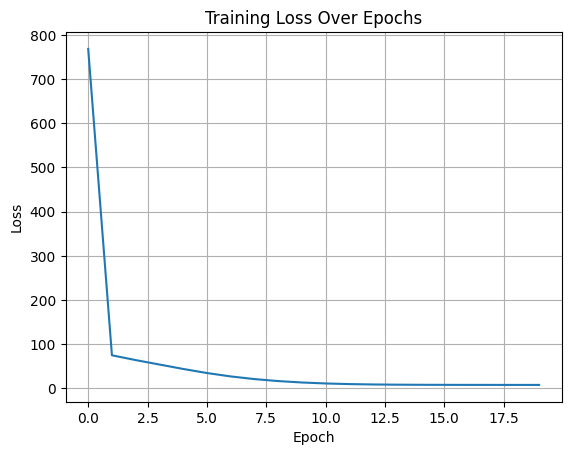

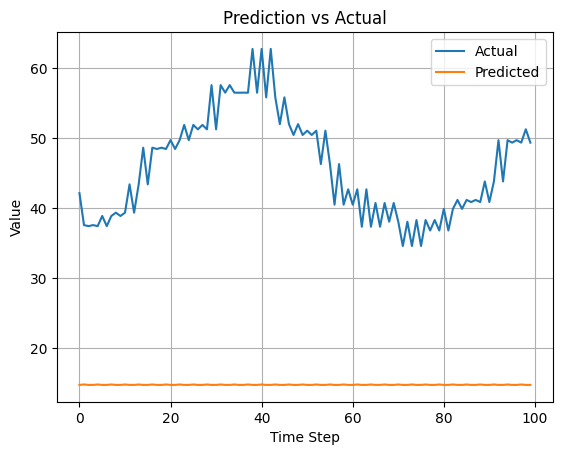

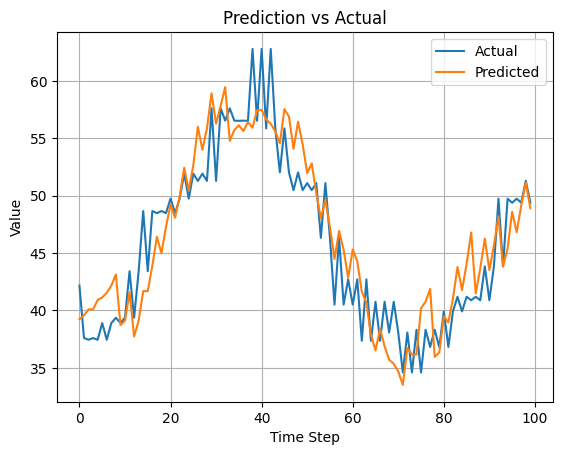

gru -> mse: 1274.4930419921875 mae: 34.77110290527344 rmse: 35.700042604907175


In [20]:
#step 1:convert time series into supervised learning format using sliding windows
#each input x contains past 14 values and each y contains next 3 values
X, y=create_sequences(data, window_size=14, horizon=3)

print(X.shape, y.shape)


#step 2: perform chronological train-test split
split = int(0.8 * len(X))

X_train, X_test=X[:split], X[split:]
y_train, y_test=y[:split], y[split:]


#step 3: convert numpy arrays to pytorch tensors
import torch

X_train=torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train=torch.tensor(y_train, dtype=torch.float32)

X_test=torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test=torch.tensor(y_test, dtype=torch.float32)


# step 4: create dataloaders for efficiency
from torch.utils.data import DataLoader, TensorDataset

train_loader=DataLoader(TensorDataset(X_train, y_train), batch_size=32)
test_loader =DataLoader(TensorDataset(X_test, y_test), batch_size=32)


# step 5: initialize models
model_gru = CustomGRU(input_size=1, hidden_size=14, output_size=3)
model_mlp = MLP(input_size=14, output_size=3)


# step 6:define loss function and optimizers
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()

optimizer_gru =optim.Adam(model_gru.parameters(), lr=0.001)
optimizer_mlp=optim.Adam(model_mlp.parameters(), lr=0.001)


#step 7: train both models
losses_gru = train_model(model_gru, train_loader, optimizer_gru, criterion)
losses_mlp = train_model(model_mlp, train_loader, optimizer_mlp, criterion)


#step 8: plot training loss curves
plot_loss(losses_gru)
plot_loss(losses_mlp)


#step 9: generate predictions on unseen test data
preds_gru, actuals = get_predictions(model_gru, test_loader)
preds_mlp, _ = get_predictions(model_mlp, test_loader)


#step 10: plot predicted vs actual
plot_predictions(actuals.flatten(), preds_gru.flatten())
plot_predictions(actuals.flatten(), preds_mlp.flatten())


#step 11: compute evaluation metrics
mse, mae, rmse = evaluate(actuals.flatten(), preds_gru.flatten())

print("gru -> mse:", mse, "mae:", mae, "rmse:", rmse)



window_sizes = [7, 14, 28]

Epoch 1, Loss: 2580.6639
Epoch 2, Loss: 2520.2347
Epoch 3, Loss: 2398.3619
Epoch 4, Loss: 2259.5698
Epoch 5, Loss: 2162.5306
Epoch 6, Loss: 2063.4213
Epoch 7, Loss: 1973.5024
Epoch 8, Loss: 1897.9669
Epoch 9, Loss: 1828.1361
Epoch 10, Loss: 1762.1840
Epoch 11, Loss: 1699.2914
Epoch 12, Loss: 1638.9862
Epoch 13, Loss: 1580.9605
Epoch 14, Loss: 1524.9970
Epoch 15, Loss: 1470.9337
Epoch 16, Loss: 1418.6443
Epoch 17, Loss: 1368.0272
Epoch 18, Loss: 1318.9983
Epoch 19, Loss: 1271.4861
Epoch 20, Loss: 1225.4290


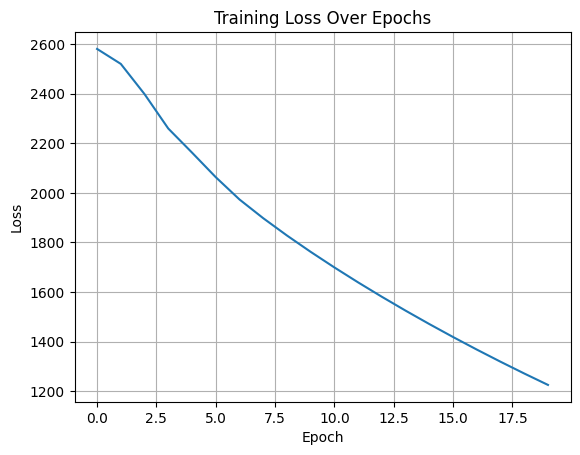

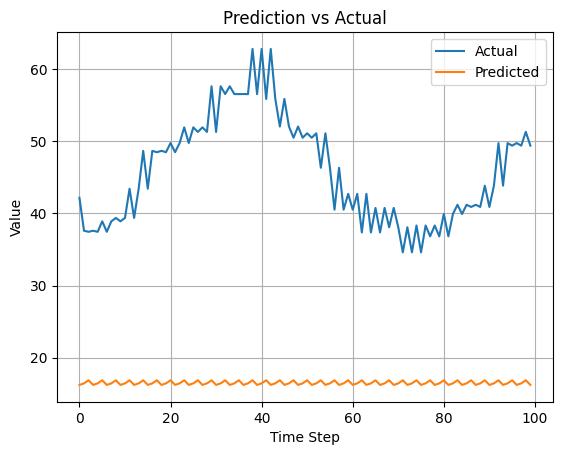

lstm -> mse: 1155.456298828125 mae: 33.01435089111328 rmse: 33.992003454167346


In [22]:
#comparison
import torch.nn as nn

#lstm model uses builtin gated mechanism to capture long-term dependencies
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.lstm=nn.LSTM(input_size,hidden_size,batch_first=True)
        self.fc=nn.Linear(hidden_size,output_size)

    def forward(self,x):
        out,_=self.lstm(x)
        out=out[:,-1,:]
        return self.fc(out)
model_lstm=LSTMModel(input_size=1,hidden_size=14,output_size=3)

optimizer_lstm=torch.optim.Adam(model_lstm.parameters(),lr=0.001)

losses_lstm=train_model(model_lstm,train_loader,optimizer_lstm,criterion)

plot_loss(losses_lstm)

preds_lstm,_=get_predictions(model_lstm,test_loader)

plot_predictions(actuals.flatten(),preds_lstm.flatten())

mse,mae,rmse=evaluate(actuals.flatten(),preds_lstm.flatten())

print("lstm -> mse:",mse,"mae:",mae,"rmse:",rmse)

Epoch 1, Loss: 2445.6186
Epoch 2, Loss: 2350.0441
Epoch 3, Loss: 2229.2435
Epoch 4, Loss: 2082.7272
Epoch 5, Loss: 1919.3240
Epoch 6, Loss: 1743.3474
Epoch 7, Loss: 1558.5403
Epoch 8, Loss: 1371.3892
Epoch 9, Loss: 1186.4418
Epoch 10, Loss: 1008.4239
Epoch 11, Loss: 842.4720
Epoch 12, Loss: 691.3649
Epoch 13, Loss: 557.3904
Epoch 14, Loss: 442.7252
Epoch 15, Loss: 346.6204
Epoch 16, Loss: 269.2927
Epoch 17, Loss: 208.9833
Epoch 18, Loss: 163.2420
Epoch 19, Loss: 130.2467
Epoch 20, Loss: 107.0358


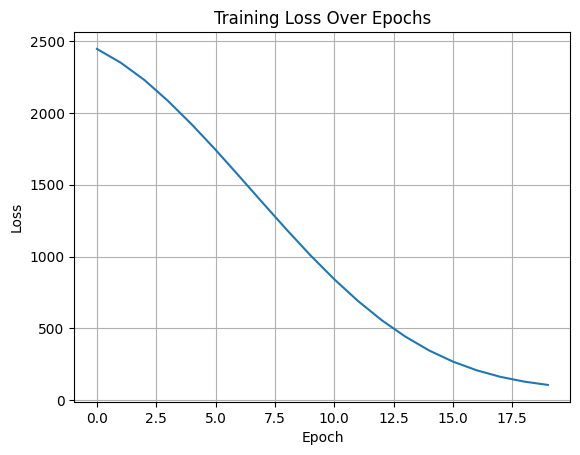

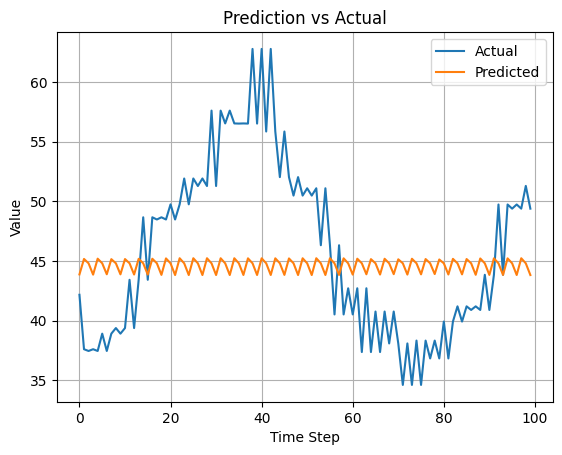

transformer -> mse: 89.99014282226562 mae: 7.808363437652588 rmse: 9.486313447397025


In [21]:
class TransformerModel(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.embedding=nn.Linear(input_size,hidden_size)

        encoder_layer=nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=2,
            batch_first=True
        )

        self.transformer=nn.TransformerEncoder(encoder_layer,num_layers=1)

        self.fc=nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x=self.embedding(x)
        x=self.transformer(x)
        x=x[:,-1,:]
        return self.fc(x)
model_trans=TransformerModel(input_size=1,hidden_size=14,output_size=3)

optimizer_trans=torch.optim.Adam(model_trans.parameters(),lr=0.001)

losses_trans=train_model(model_trans,train_loader,optimizer_trans,criterion)

plot_loss(losses_trans)

preds_trans,_=get_predictions(model_trans,test_loader)

plot_predictions(actuals.flatten(),preds_trans.flatten())

mse,mae,rmse=evaluate(actuals.flatten(),preds_trans.flatten())

print("transformer -> mse:",mse,"mae:",mae,"rmse:",rmse)